# agentv22_multimodal_agent

This version introduces image input.

Graph:

```text
START → prepare_image → vision_analysis → final_answer → END
```


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter pillow
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter pillow


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define state using NotRequired


In [3]:
from typing import NotRequired, TypedDict

class AgentState(TypedDict):
    input: str
    image_path: NotRequired[str]
    image_base64: NotRequired[str]
    image_mime_type: NotRequired[str]
    visual_observations: NotRequired[str]
    final_answer: NotRequired[str]


## 4. Create sample dashboard image


In [4]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

SAMPLE_IMAGE_PATH = Path("sample_dashboard.png")

def create_sample_dashboard(path: Path = SAMPLE_IMAGE_PATH) -> Path:
    img = Image.new("RGB", (1000, 620), "white")
    draw = ImageDraw.Draw(img)

    try:
        title_font = ImageFont.truetype("DejaVuSans-Bold.ttf", 28)
        label_font = ImageFont.truetype("DejaVuSans.ttf", 18)
        small_font = ImageFont.truetype("DejaVuSans.ttf", 14)
    except Exception:
        title_font = label_font = small_font = None

    draw.text((40, 30), "EPP SLA Monitoring Dashboard - Release R13", fill="black", font=title_font)
    draw.rectangle((40, 90, 470, 300), outline="black", width=2)
    draw.rectangle((530, 90, 960, 300), outline="black", width=2)
    draw.rectangle((40, 350, 960, 570), outline="black", width=2)

    draw.text((60, 105), "CHECK-DOMAIN p95 response_time", fill="black", font=label_font)
    draw.text((550, 105), "Failure reasons", fill="black", font=label_font)
    draw.text((60, 365), "Volume and timeout trend", fill="black", font=label_font)

    points = [(80, 250), (140, 235), (200, 230), (260, 210), (320, 160), (380, 135), (440, 130)]
    draw.line(points, fill="black", width=4)
    for x, y in points:
        draw.ellipse((x - 4, y - 4, x + 4, y + 4), fill="black")
    draw.text((75, 265), "Before R13", fill="gray", font=small_font)
    draw.text((335, 265), "After R13", fill="gray", font=small_font)
    draw.text((350, 145), "p95 ~240 ms", fill="black", font=small_font)

    bars = [("CONNECTION_TIMEOUT", 150), ("AUTH_FAILED", 70), ("INVALID_TLD", 45), ("QUOTA_EXCEEDED", 35)]
    y = 150
    for label, width in bars:
        draw.text((550, y), label, fill="black", font=small_font)
        draw.rectangle((730, y, 730 + width, y + 22), fill="lightgray", outline="black")
        draw.text((740 + width, y + 2), str(width), fill="black", font=small_font)
        y += 35

    volume_points = [(80, 520), (200, 500), (320, 470), (440, 430), (560, 390), (680, 385), (900, 380)]
    timeout_points = [(80, 540), (200, 535), (320, 525), (440, 480), (560, 430), (680, 410), (900, 405)]
    draw.line(volume_points, fill="black", width=3)
    draw.line(timeout_points, fill="gray", width=3)
    draw.text((80, 530), "Volume", fill="black", font=small_font)
    draw.text((80, 550), "Timeouts", fill="gray", font=small_font)
    draw.text((740, 400), "Timeouts elevated after release", fill="black", font=small_font)

    img.save(path)
    return path

image_path = create_sample_dashboard()
image_path


PosixPath('sample_dashboard.png')

## 5. Display sample image


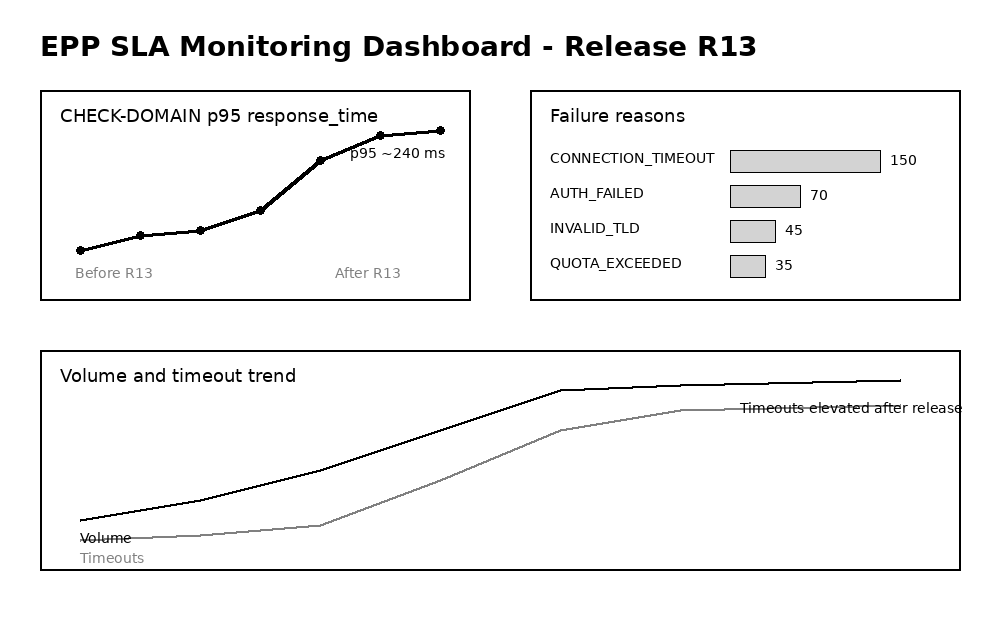

In [5]:
from IPython.display import Image as IPImage, display

display(IPImage(filename=str(image_path)))


## 6. Encode image as base64


In [6]:
import base64

def encode_image(path: str | Path) -> tuple[str, str]:
    image_path = Path(path)
    suffix = image_path.suffix.lower()
    mime_type = "image/png" if suffix == ".png" else "image/jpeg"
    encoded = base64.b64encode(image_path.read_bytes()).decode("utf-8")
    return encoded, mime_type

encoded, mime_type = encode_image(image_path)
print("MIME:", mime_type)
print("Encoded chars:", len(encoded))


MIME: image/png
Encoded chars: 43012


## 7. Define graph nodes


In [7]:
from langchain_openai import ChatOpenAI

def prepare_image_node(state: AgentState) -> AgentState:
    image_path = Path(state.get("image_path") or create_sample_dashboard())

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    encoded, mime_type = encode_image(image_path)
    return {"image_path": str(image_path), "image_base64": encoded, "image_mime_type": mime_type}

def vision_analysis_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    data_url = f"data:{state['image_mime_type']};base64,{state['image_base64']}"

    message = [
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "Analyze this monitoring dashboard image. "
                        "Extract visible signals, anomalies, metrics, and likely operational meaning. "
                        f"User question: {state['input']}"
                    ),
                },
                {"type": "image_url", "image_url": {"url": data_url}},
            ],
        }
    ]

    response = llm.invoke(message)
    return {"visual_observations": response.content}

def final_answer_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    prompt = f'''
User question:
{state["input"]}

Visual observations:
{state["visual_observations"]}

Write a concise final answer with:
1. what the image shows
2. likely incident interpretation
3. recommended next action
'''
    response = llm.invoke(prompt)
    return {"final_answer": response.content}


## 8. Build graph


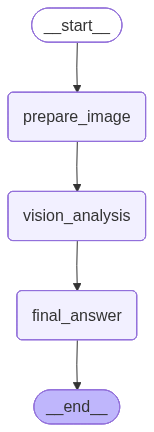

In [8]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("prepare_image", prepare_image_node)
    graph_builder.add_node("vision_analysis", vision_analysis_node)
    graph_builder.add_node("final_answer", final_answer_node)

    graph_builder.add_edge(START, "prepare_image")
    graph_builder.add_edge("prepare_image", "vision_analysis")
    graph_builder.add_edge("vision_analysis", "final_answer")
    graph_builder.add_edge("final_answer", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 9. Visualize graph


In [9]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	prepare_image(prepare_image)
	vision_analysis(vision_analysis)
	final_answer(final_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> prepare_image;
	prepare_image --> vision_analysis;
	vision_analysis --> final_answer;
	final_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 10. Run multimodal graph


In [10]:
result = graph.invoke({
    "input": "What does this EPP monitoring dashboard show?",
    "image_path": str(image_path),
})

print(result["final_answer"])


The EPP SLA Monitoring Dashboard for Release R13 shows a significant increase in the p95 response time for the CHECK-DOMAIN operation, rising to approximately 240 ms, along with a steady increase in request volume and a notable rise in timeout occurrences post-release. 

This indicates that the R13 release has negatively impacted system performance, leading to higher response times and connection timeouts, which suggests users are experiencing difficulties accessing the CHECK-DOMAIN functionality.

It is recommended to conduct a thorough investigation into the changes made in the R13 release to identify and address the performance bottlenecks and reliability issues. Immediate actions should be taken to mitigate user impact and restore service levels.


## 11. Inspect visual observations


In [11]:
print(result["visual_observations"])


The EPP SLA Monitoring Dashboard for Release R13 presents several key insights regarding system performance and operational issues:

### Visible Signals and Metrics:
1. **P95 Response Time**:
   - The graph shows the p95 response time for the CHECK-DOMAIN operation, indicating a significant increase to approximately 240 ms after the R13 release.
   - This suggests a degradation in performance compared to the period before the release.

2. **Volume and Timeout Trend**:
   - The volume of requests is shown to be increasing steadily.
   - Timeout occurrences have also risen, particularly after the R13 release, indicating potential issues with system responsiveness or capacity.

### Anomalies:
- The sharp increase in p95 response time and the elevated timeout rates post-release are notable anomalies. This could indicate that the new release introduced performance bottlenecks or issues that were not present before.

### Failure Reasons:
- The dashboard lists several failure reasons with cor

## 12. Stream graph updates


In [12]:
for chunk in graph.stream(
    {"input": "What does this dashboard show?", "image_path": str(image_path)},
    stream_mode="updates",
):
    print("\n--- update ---")
    print(chunk.keys())



--- update ---
dict_keys(['prepare_image'])

--- update ---
dict_keys(['vision_analysis'])

--- update ---
dict_keys(['final_answer'])
